# **Importações**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Carregar Dados e Visualização Simples**

Primeiras linhas do dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

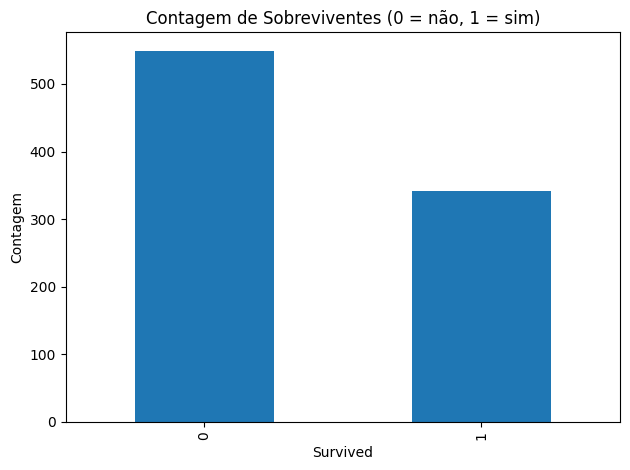

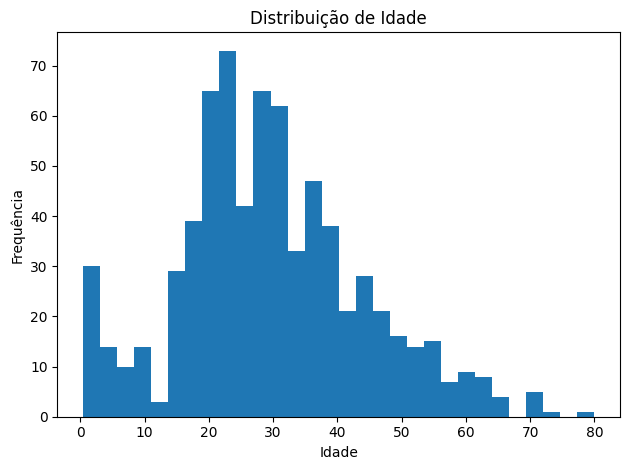

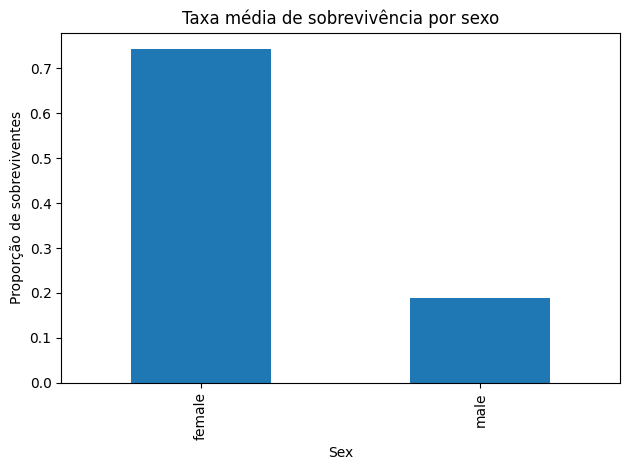

In [8]:
df = pd.read_csv("titanic-dataset.csv")

print("Primeiras linhas do dataset:")
print(df.head(), "\n")

print("Informações gerais:")
print(df.info(), "\n")

print("Estatísticas descritivas das variáveis numéricas:")
print(df.describe(), "\n")

print("Distribuição da Survived:")
print(df["Survived"].value_counts(normalize=True) * 100)

plt.figure()
df["Survived"].value_counts().plot(
    kind="bar",
    title="Contagem de Sobreviventes (0 = não, 1 = sim)"
)
plt.xlabel("Survived")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()

plt.figure()
df["Age"].plot(kind="hist", bins=30)
plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure()
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Taxa média de sobrevivência por sexo")
plt.ylabel("Proporção de sobreviventes")
plt.tight_layout()
plt.show()

# **Pré Processamento**

In [9]:
df_prep = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
print("\nValores ausentes por coluna :")
print(df_prep.isnull().sum())

df_prep["Age"].fillna(df_prep["Age"].median(), inplace=True)

df_prep["Embarked"].fillna(df_prep["Embarked"].mode()[0], inplace=True)

print("\nValores ausentes por coluna após o tratamento:")
print(df_prep.isnull().sum())

df_prep = pd.get_dummies(df_prep, columns=["Sex", "Embarked"], drop_first=True)

X = df_prep.drop(columns=["Survived"])
y = df_prep["Survived"]

print("\nColunas finais de features:")
print(X.columns)

from sklearn.preprocessing import StandardScaler

numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


Valores ausentes por coluna :
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Valores ausentes por coluna após o tratamento:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Colunas finais de features:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')


/tmp/ipython-input-812174312.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prep["Age"].fillna(df_prep["Age"].median(), inplace=True)
/tmp/ipython-input-812174312.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

# **Treino e Teste dos Dados já Separados**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamanhos dos conjuntos:")
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)



Tamanhos dos conjuntos:
Treino: (712, 8)
Teste: (179, 8)


# **Treinamento do Modelo de Árvore de Decisão**

In [11]:
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

# **Avaliação do Modelo**


Acurácia no conjunto de teste: 0.7877094972067039

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179

Matriz de confusão:
[[103   7]
 [ 31  38]]


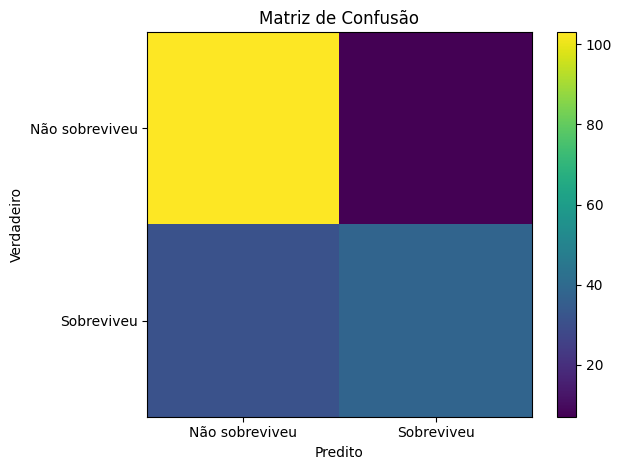

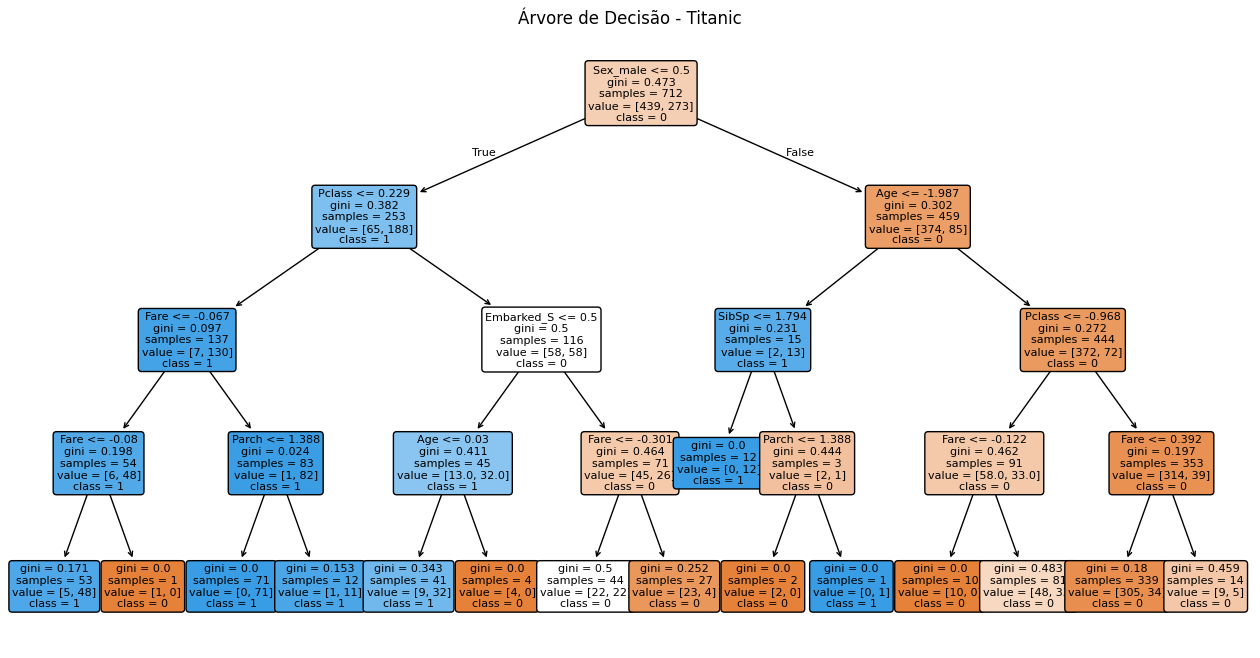

In [12]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nAcurácia no conjunto de teste:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(cm)

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Não sobreviveu", "Sobreviveu"])
plt.yticks(tick_marks, ["Não sobreviveu", "Sobreviveu"])

plt.ylabel("Verdadeiro")
plt.xlabel("Predito")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árvore de Decisão - Titanic")
plt.show()